In [5]:
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings('ignore')

In [6]:
df = pd.read_csv('../data/raw/ec2_cpu_utilization_24ae8d.csv', parse_dates=['timestamp'])
df = df.set_index('timestamp')
df = df.asfreq('5min')  # garante que o statsmodels reconheça a frequência explicitamente

tamanho_treino = int(len(df) * 0.8)
treino = df['value'].iloc[:tamanho_treino]
teste = df['value'].iloc[tamanho_treino:]

print(f'Treino: {len(treino)} pontos | Teste: {len(teste)} pontos')

Treino: 3225 pontos | Teste: 807 pontos


In [7]:
candidatos = [
    {'order': (0, 0, 0), 'seasonal_order': (1, 0, 0, 288)},
    {'order': (1, 0, 0), 'seasonal_order': (1, 0, 0, 288)},
    {'order': (0, 0, 1), 'seasonal_order': (1, 0, 0, 288)},
]

In [ ]:

def termos_fourier(indice, periodo, n_harmonicos):
    t = np.arange(len(indice))
    termos = {}
    for k in range(1, n_harmonicos + 1):
        termos[f'seno_{k}'] = np.sin(2 * np.pi * k * t / periodo)
        termos[f'cos_{k}'] = np.cos(2 * np.pi * k * t / periodo)
    return pd.DataFrame(termos, index=indice)

N_HARMONICOS = 3  # Por conta de erros de memória

exog_treino = termos_fourier(treino.index, periodo=288, n_harmonicos=N_HARMONICOS)
exog_teste = termos_fourier(teste.index, periodo=288, n_harmonicos=N_HARMONICOS)
exog_teste.index = teste.index
t_offset = len(treino)
for k in range(1, N_HARMONICOS + 1):
    t_teste = np.arange(t_offset, t_offset + len(teste))
    exog_teste[f'seno_{k}'] = np.sin(2 * np.pi * k * t_teste / 288)
    exog_teste[f'cos_{k}'] = np.cos(2 * np.pi * k * t_teste / 288)

In [9]:
candidatos = [
    {'order': (0, 0, 0)},
    {'order': (1, 0, 0)},
    {'order': (0, 0, 1)},
]

resultados = []
for cand in candidatos:
    inicio = time.time()
    print(f"Treinando order={cand['order']} + Fourier(k={N_HARMONICOS}) ...")

    modelo = SARIMAX(
        treino,
        exog=exog_treino,
        order=cand['order'],
        seasonal_order=(0, 0, 0, 0), 
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    fit = modelo.fit(method='lbfgs', maxiter=100, disp=False)

    duracao = time.time() - inicio
    print(f'  AIC: {fit.aic:.2f} | tempo: {duracao:.1f}s\n')
    resultados.append({'order': cand['order'], 'aic': fit.aic, 'fit': fit})

Treinando order=(0, 0, 0) + Fourier(k=3) ...
  AIC: -3020.37 | tempo: 1.3s

Treinando order=(1, 0, 0) + Fourier(k=3) ...
  AIC: -4835.25 | tempo: 1.7s

Treinando order=(0, 0, 1) + Fourier(k=3) ...
  AIC: -3969.93 | tempo: 1.3s



In [10]:
melhor = min(resultados, key=lambda r: r['aic'])
print(f"Melhor modelo: order={melhor['order']} (AIC={melhor['aic']:.2f})")
modelo_final = melhor['fit']

Melhor modelo: order=(1, 0, 0) (AIC=-4835.25)


In [ ]:
previsao = modelo_final.get_forecast(steps=len(teste), exog=exog_teste)
media_prevista = previsao.predicted_mean
intervalo_confianca = previsao.conf_int(alpha=0.05)

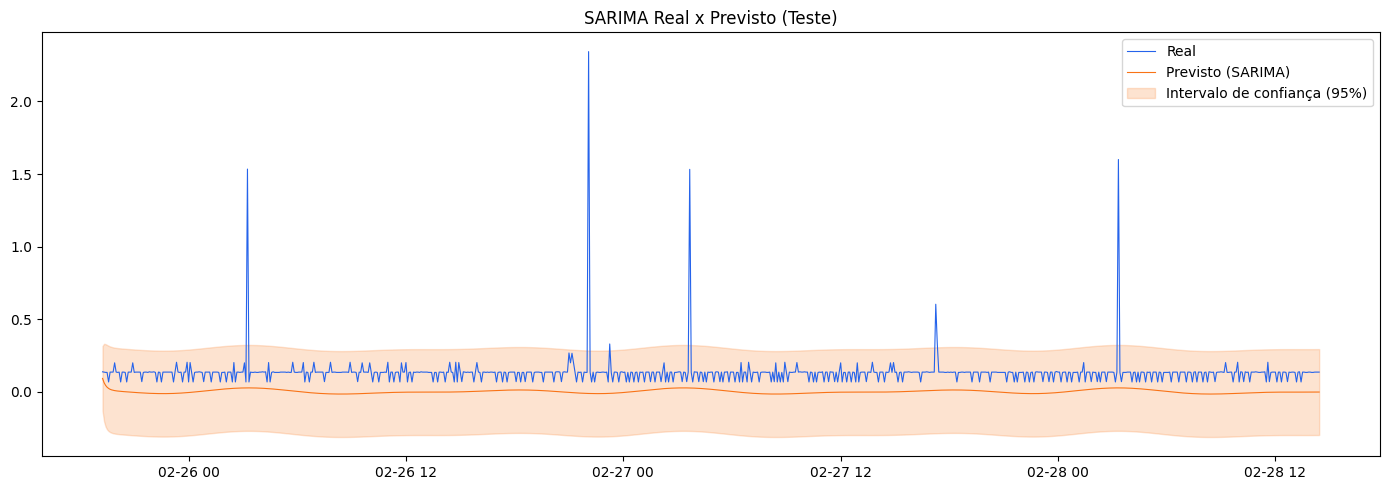

In [13]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(teste.index, teste.values, label='Real', color='#2563eb', linewidth=0.8)
ax.plot(media_prevista.index, media_prevista.values, label='Previsto (SARIMA)', color='#f97316', linewidth=0.8)
ax.fill_between(
    intervalo_confianca.index,
    intervalo_confianca.iloc[:, 0],
    intervalo_confianca.iloc[:, 1],
    color='#f97316', alpha=0.2, label='Intervalo de confiança (95%)'
)
ax.set_title('SARIMA Real x Previsto (Teste)')
ax.legend()
plt.tight_layout()
plt.show()